# 01 — Telemetry Exploration: Monaco GP 2026

Goal of this notebook:
1. Load the 2026 Monaco Grand Prix race session via FastF1
2. Understand the structure of a `Session` and a `Lap` object
3. Identify a fast, clean lap suitable for telemetry analysis
4. Plot the basic telemetry channels and identify braking events
5. Build initial intuition for what 2026 brake telemetry actually looks like

Monaco is chosen because it has the densest braking-event profile of any 2026 race — every lap is a chain of heavy braking zones, which is exactly what we want for a brake-focused project.

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit nicer by default
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print(f"FastF1 version: {fastf1.__version__}")
print(f"Pandas version: {pd.__version__}")

#when something breaks later, version mismatches are one of the first things to check. 

FastF1 version: 3.8.3
Pandas version: 2.3.3


In [2]:
# Enable the FastF1 cache so we don't re-download every time
# Path is relative to where the notebook is run from
fastf1.Cache.enable_cache('../data/raw')

#FastF1 pulls data from the official F1 timing API and from open-source archives. The first time you load a session it downloads everything; subsequent loads read from disk. The cache will live in data/raw/ which is gitignore'd, so it won't bloat the repo.

In [3]:
# Load 2026 Monaco GP QUALIFYING
# 'Q' = Qualifying session
session = fastf1.get_session(2026, 'Monaco', 'Q')

session.load(laps=True, telemetry=True, weather=True, messages=False)

print(f"Loaded: {session.event['EventName']} - {session.name}")
print(f"Date: {session.date}")
print(f"Total laps in session data: {len(session.laps)}")

#What session.load() does: pulls down the lap timings, per-lap telemetry, weather, and skips race control messages (we don't need them yet). 

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']


Loaded: Monaco Grand Prix - Qualifying
Date: 2026-06-06 14:00:00
Total laps in session data: 484


In [4]:
# Top of the results table — who finished where
print("=== Race Result (Top 10) ===")
print(session.results[['Position', 'Abbreviation', 'TeamName', 'Time', 'Status']].head(10))

print("\n=== Weather Summary ===")
weather = session.weather_data
print(f"Air temp:     {weather['AirTemp'].mean():.1f} °C  (min {weather['AirTemp'].min():.1f}, max {weather['AirTemp'].max():.1f})")
print(f"Track temp:   {weather['TrackTemp'].mean():.1f} °C  (min {weather['TrackTemp'].min():.1f}, max {weather['TrackTemp'].max():.1f})")
print(f"Humidity:     {weather['Humidity'].mean():.1f} %")
print(f"Rain flag:    {weather['Rainfall'].any()}")

#before any analysis, you sanity-check what you're working with. Was it wet? Were temperatures stable? Did the race go full distance? If we see Rain flag: True, our entire braking analysis just got a lot messier — we'd want to either pick a different session or restrict to dry laps.

=== Race Result (Top 10) ===
    Position Abbreviation         TeamName Time Status
12       1.0          ANT         Mercedes  NaT       
3        2.0          VER  Red Bull Racing  NaT       
44       3.0          HAM          Ferrari  NaT       
16       4.0          LEC          Ferrari  NaT       
6        5.0          HAD  Red Bull Racing  NaT       
63       6.0          RUS         Mercedes  NaT       
81       7.0          PIA          McLaren  NaT       
1        8.0          NOR          McLaren  NaT       
10       9.0          GAS           Alpine  NaT       
30      10.0          LAW     Racing Bulls  NaT       

=== Weather Summary ===
Air temp:     23.7 °C  (min 23.0, max 24.5)
Track temp:   38.5 °C  (min 32.3, max 47.4)
Humidity:     54.9 %
Rain flag:    False


In [5]:
# In qualifying, we don't use pick_quicklaps() — that filter is for filtering out
# slow race laps (in-laps, out-laps, SC laps). In qualifying every lap is either
# a flying lap, an out-lap, or an in-lap, and the lap times themselves cleanly
# distinguish them.

# Just pick the single fastest lap of the session — this is the pole position lap
fastest = session.laps.pick_fastest()

print(f"Pole position lap:")
print(f"  Driver:        {fastest['Driver']} ({fastest['Team']})")
print(f"  Lap number:    {int(fastest['LapNumber'])}")
print(f"  Lap time:      {fastest['LapTime']}")
print(f"  Compound:      {fastest['Compound']}")
print(f"  Tyre age:      {int(fastest['TyreLife'])} laps")
print(f"  Sector 1:      {fastest['Sector1Time']}")
print(f"  Sector 2:      {fastest['Sector2Time']}")
print(f"  Sector 3:      {fastest['Sector3Time']}")

Pole position lap:
  Driver:        ANT (Mercedes)
  Lap number:    27
  Lap time:      0 days 00:01:12.051000
  Compound:      SOFT
  Tyre age:      3 laps
  Sector 1:      0 days 00:00:18.934000
  Sector 2:      0 days 00:00:33.989000
  Sector 3:      0 days 00:00:19.128000


In [6]:
# get_telemetry() returns a DataFrame combining car data (speed, throttle, brake, etc.)
# with position data (X, Y, Z) and adds derived columns like Distance and
# RelativeDistance (position along the lap, very useful for plotting).
tel = fastest.get_telemetry()

print(f"Telemetry shape: {tel.shape}  (rows × columns)")
print(f"Telemetry columns:\n{list(tel.columns)}")
print(f"\nFirst 3 rows:")
tel.head(3)

#each row is one sample in time (FastF1 typically interpolates to a uniform grid; expect ~5–10ms per sample, so a 72-second lap gives several thousand rows). The columns are the channels we listed in the scope doc.

Telemetry shape: (539, 18)  (rows × columns)
Telemetry columns:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']

First 3 rows:


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2026-06-06 15:06:27.660,0 days 01:20:41.350000,,301.426944,0 days 00:00:00,11970.177333,269.945456,6,100.0,False,0,interpolation,0.482576,0.000147,OnTrack,-7667.616875,-6561.850493,502.256618
3,2026-06-06 15:06:27.666,0 days 01:20:41.356000,,301.426944,0 days 00:00:00.006000,11973.000000,270.000000,6,100.0,False,0,car,0.932222,0.000284,OnTrack,-7668.054515,-6557.006943,502.281812
4,2026-06-06 15:06:27.866,0 days 01:20:41.556000,10,301.426944,0 days 00:00:00.206000,12039.000000,270.000000,6,100.0,False,0,car,15.932222,0.004855,OnTrack,-7677.391237,-6385.768243,502.923469


In [7]:
# Check the channels we care about
channels = ['Speed', 'Throttle', 'Brake', 'nGear', 'RPM', 'Distance']

for col in channels:
    if col in tel.columns:
        s = tel[col]
        # Brake is boolean, others are numeric
        if s.dtype == bool:
            print(f"{col:12s} | dtype={str(s.dtype):8s} | True samples: {s.sum()}/{len(s)} ({s.mean()*100:.1f}%)")
        else:
            print(f"{col:12s} | dtype={str(s.dtype):8s} | min={s.min():>8.2f}  max={s.max():>8.2f}  mean={s.mean():>8.2f}")
    else:
        print(f"{col:12s} | NOT PRESENT")

print(f"\nLap distance covered: {tel['Distance'].iloc[-1]:.0f} m")
print(f"Number of samples on this lap: {len(tel)}")
print(f"Effective sample rate: {len(tel) / fastest['LapTime'].total_seconds():.1f} Hz")

Speed        | dtype=float64  | min=   44.00  max=  289.00  mean=  163.43
Throttle     | dtype=float64  | min=    0.00  max=  100.00  mean=   52.57
Brake        | dtype=bool     | True samples: 147/539 (27.3%)
nGear        | dtype=int64    | min=    1.00  max=    7.00  mean=    3.35
RPM          | dtype=float64  | min= 4668.00  max=13040.00  mean=10570.31
Distance     | dtype=float64  | min=    0.48  max= 3269.82  mean= 1659.75

Lap distance covered: 3270 m
Number of samples on this lap: 539
Effective sample rate: 7.5 Hz


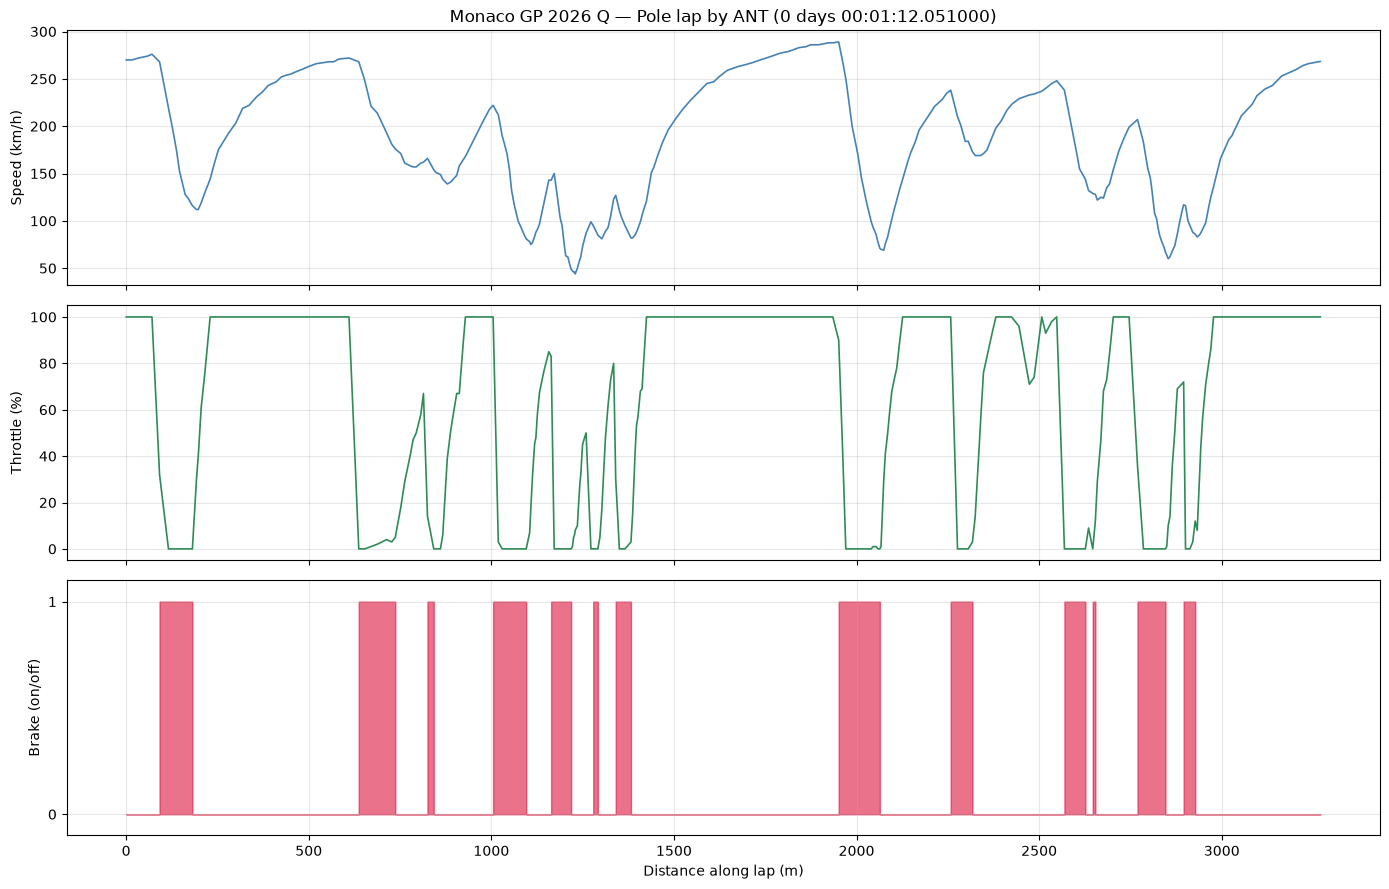

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Speed over distance
axes[0].plot(tel['Distance'], tel['Speed'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title(f"Monaco GP 2026 Q — Pole lap by {fastest['Driver']} ({fastest['LapTime']})")
axes[0].grid(True, alpha=0.3)

# Throttle as a percentage
axes[1].plot(tel['Distance'], tel['Throttle'], color='seagreen', linewidth=1.2)
axes[1].set_ylabel('Throttle (%)')
axes[1].set_ylim(-5, 105)
axes[1].grid(True, alpha=0.3)

# Brake as shaded regions (since it's boolean, a line plot is ugly)
# We'll fill in red where the driver is braking
axes[2].fill_between(tel['Distance'], 0, tel['Brake'].astype(int),
                     color='crimson', alpha=0.6, step='post')
axes[2].set_ylabel('Brake (on/off)')
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_yticks([0, 1])
axes[2].set_xlabel('Distance along lap (m)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# A "braking event" is a contiguous stretch where Brake == True.
# To find them, we look at where Brake transitions from False -> True (start)
# and True -> False (end).

brake = tel['Brake'].astype(int).values  # 0/1 array
# np.diff gives us +1 at the start of each braking event, -1 at the end
edges = np.diff(brake, prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1  # -1 because diff shifts by one

# Sanity: number of starts should equal number of ends
assert len(starts) == len(ends), "Mismatched start/end counts — something is off"

print(f"Number of braking events detected: {len(starts)}")

# Build a small table summarizing each event
events = []
for i, (s_idx, e_idx) in enumerate(zip(starts, ends)):
    d_start = tel['Distance'].iloc[s_idx]
    d_end = tel['Distance'].iloc[e_idx]
    v_start = tel['Speed'].iloc[s_idx]
    v_end = tel['Speed'].iloc[e_idx]
    t_start = tel['Time'].iloc[s_idx].total_seconds()
    t_end = tel['Time'].iloc[e_idx].total_seconds()
    duration = t_end - t_start

    events.append({
        'event': i + 1,
        'dist_start_m': round(d_start, 0),
        'dist_end_m': round(d_end, 0),
        'duration_s': round(duration, 3),
        'v_start_kmh': round(v_start, 1),
        'v_end_kmh': round(v_end, 1),
        'delta_v_kmh': round(v_start - v_end, 1),
    })

events_df = pd.DataFrame(events)
print("\nBraking events on this lap:")
events_df

#np.diff computes the difference between each pair of consecutive samples. If brake goes from 0 to 1, the diff is +1 (event starts). If it goes from 1 to 0, the diff is -1 (event ends). The prepend=0, append=0 is a trick to make sure we catch events that start at the very first sample or end at the very last one.
#Then for each event we record where it happens on track, how long it lasted, and what the speed change was. The speed change (delta_v_kmh) is your immediate proxy for how heavy the braking was — a 200 km/h speed loss is a much bigger event than a 30 km/h brush.

Number of braking events detected: 13

Braking events on this lap:


,event,dist_start_m,dist_end_m,duration_s,v_start_kmh,v_end_kmh,delta_v_kmh
0,1,92.0,178.0,1.977,268.0,118.3,149.7
1,2,637.0,730.0,1.617,268.0,179.6,88.4
2,3,825.0,835.0,0.238,166.0,158.9,7.1
3,4,1005.0,1090.0,2.316,222.0,85.3,136.7
4,5,1164.0,1218.0,2.337,143.0,50.1,92.9
5,6,1279.0,1288.0,0.377,95.0,87.9,7.1
6,7,1341.0,1366.0,0.880,127.0,95.0,32.0
7,8,1951.0,2063.0,3.057,289.0,71.6,217.4
8,9,2258.0,2306.0,0.880,238.0,184.0,54.0
9,10,2569.0,2622.0,1.257,238.0,146.8,91.2


In [10]:
MIN_DURATION_S = 0.1   # filter single-sample blips
MIN_DELTA_V_KMH = 5.0  # filter events with no real physical work

events_clean = events_df[
    (events_df['duration_s'] >= MIN_DURATION_S) &
    (events_df['delta_v_kmh'] >= MIN_DELTA_V_KMH)
].reset_index(drop=True)

removed = len(events_df) - len(events_clean)
print(f"Events before filter: {len(events_df)}")
print(f"Events removed:       {removed}")
print(f"Events after filter:  {len(events_clean)}")
print(f"\nFiltered events (original event numbers preserved):")
events_clean

#the original 1-13 event numbers are preserved in the event column so we can still trace back to which event was which. The filter just drops rows; it doesn't renumber.

Events before filter: 13
Events removed:       1
Events after filter:  12

Filtered events (original event numbers preserved):


,event,dist_start_m,dist_end_m,duration_s,v_start_kmh,v_end_kmh,delta_v_kmh
0,1,92.0,178.0,1.977,268.0,118.3,149.7
1,2,637.0,730.0,1.617,268.0,179.6,88.4
2,3,825.0,835.0,0.238,166.0,158.9,7.1
3,4,1005.0,1090.0,2.316,222.0,85.3,136.7
4,5,1164.0,1218.0,2.337,143.0,50.1,92.9
5,6,1279.0,1288.0,0.377,95.0,87.9,7.1
6,7,1341.0,1366.0,0.880,127.0,95.0,32.0
7,8,1951.0,2063.0,3.057,289.0,71.6,217.4
8,9,2258.0,2306.0,0.880,238.0,184.0,54.0
9,10,2569.0,2622.0,1.257,238.0,146.8,91.2


In [11]:
# Vehicle mass during this Q3 lap (approximate, will be refined in parameter derivation)
#   - 768 kg minimum dry car
#   - ~80 kg driver
#   - ~5 kg fuel (Q3 runs near-empty)
M_CAR = 850  # kg

# Brake bias to front axle (from scope decision)
BRAKE_BIAS_FRONT = 0.56

# Convert km/h to m/s
v_start_ms = events_clean['v_start_kmh'] / 3.6
v_end_ms = events_clean['v_end_kmh'] / 3.6

# Kinetic energy change: ΔKE = 0.5 * m * (v_start² - v_end²)
# This is the TOTAL energy the vehicle lost during the event
events_clean['delta_KE_kJ'] = 0.5 * M_CAR * (v_start_ms**2 - v_end_ms**2) / 1000

# Front-axle share (note: this is only the BRAKE share, not the total ΔKE share —
# we have NOT yet subtracted drag, rolling resistance, or engine braking.
# Those subtractions come in the physics model. For now, ΔKE × bias is an
# UPPER BOUND on front-brake energy.)
events_clean['E_front_upper_kJ'] = events_clean['delta_KE_kJ'] * BRAKE_BIAS_FRONT

# Average power dissipated by the front axle during the event
events_clean['avg_power_front_kW'] = events_clean['E_front_upper_kJ'] / events_clean['duration_s']

print(events_clean[['event', 'dist_start_m', 'duration_s', 'delta_v_kmh',
                     'delta_KE_kJ', 'E_front_upper_kJ', 'avg_power_front_kW']])


#the column is called E_front_upper_kJ for a reason. It's an upper bound on the front-brake energy, not the actual front-brake energy.
#haven't built the drag/rolling/engine-braking model, so we're computing the simplest possible thing: what would the front brakes absorb if they had to absorb the entire ΔKE alone. 

    event  dist_start_m  duration_s  delta_v_kmh  delta_KE_kJ  \
0       1          92.0       1.977        149.7  1896.402141   
1       2         637.0       1.617         88.4  1297.556481   
2       3         825.0       0.238          7.1    75.647049   
3       4        1005.0       2.316        136.7  1377.574209   
4       5        1164.0       2.337         92.9   588.277064   
5       6        1279.0       0.377          7.1    42.584934   
6       7        1341.0       0.880         32.0   232.962963   
7       8        1951.0       3.057        217.4  2570.805324   
8       9        2258.0       0.880         54.0   747.291667   
9      10        2569.0       1.257         91.2  1150.837037   
10     12        2769.0       2.396        137.9  1248.574904   
11     13        2896.0       1.136         30.5   203.539255   

    E_front_upper_kJ  avg_power_front_kW  
0        1061.985199          537.170055  
1         726.631630          449.370210  
2          42.362347     

In [12]:
# Average deceleration = delta_v / duration, in SI units
events_clean['avg_decel_ms2'] = (events_clean['delta_v_kmh'] / 3.6) / events_clean['duration_s']
events_clean['avg_decel_g'] = events_clean['avg_decel_ms2'] / 9.81

print("Deceleration per event:")
print(events_clean[['event', 'dist_start_m', 'duration_s', 'delta_v_kmh',
                     'avg_decel_ms2', 'avg_decel_g']].to_string(index=False))

Deceleration per event:
 event  dist_start_m  duration_s  delta_v_kmh  avg_decel_ms2  avg_decel_g
     1          92.0       1.977        149.7      21.033553     2.144093
     2         637.0       1.617         88.4      15.185872     1.547999
     3         825.0       0.238          7.1       8.286648     0.844714
     4        1005.0       2.316        136.7      16.395605     1.671316
     5        1164.0       2.337         92.9      11.042172     1.125604
     6        1279.0       0.377          7.1       5.231359     0.533268
     7        1341.0       0.880         32.0      10.101010     1.029665
     8        1951.0       3.057        217.4      19.754298     2.013690
     9        2258.0       0.880         54.0      17.045455     1.737559
    10        2569.0       1.257         91.2      20.153805     2.054414
    12        2769.0       2.396        137.9      15.987294     1.629694
    13        2896.0       1.136         30.5       7.457942     0.760239


In [13]:
# Approximate mapping of original event numbers to Monaco corners
# (based on event distances and Monaco circuit layout — best-effort)
corner_map = {
    1:  "T1 Sainte-Dévote",
    2:  "T3-T4 Casino Square",
    3:  "T5 Mirabeau Haute (brush)",
    4:  "T6 Loews Hairpin approach",
    5:  "T6 Loews Hairpin / T8 Portier",
    6:  "T8 Portier (brush)",
    7:  "Tunnel entry",
    8:  "T10-T11 Nouvelle Chicane",
    9:  "T12 Tabac",
    10: "T13 Piscine entry",
    # event 11 filtered out
    12: "T17-T18 Rascasse",
    13: "T19 Anthony Noghes",
}

events_clean['corner'] = events_clean['event'].map(corner_map)

# Print a clean summary table sorted by energy
summary = events_clean[['event', 'corner', 'dist_start_m', 'duration_s', 
                         'delta_v_kmh', 'delta_KE_kJ', 'avg_power_front_kW', 
                         'avg_decel_g']].copy()
summary.columns = ['#', 'Corner', 'Dist (m)', 'Dur (s)', 'ΔV (km/h)', 
                    'ΔKE (kJ)', 'P_front (kW)', 'Decel (g)']

print("Summary of braking events at Monaco GP 2026 Q (pole lap, ANT):")
print(summary.to_string(index=False))

Summary of braking events at Monaco GP 2026 Q (pole lap, ANT):
 #                        Corner  Dist (m)  Dur (s)  ΔV (km/h)    ΔKE (kJ)  P_front (kW)  Decel (g)
 1              T1 Sainte-Dévote      92.0    1.977      149.7 1896.402141    537.170055   2.144093
 2           T3-T4 Casino Square     637.0    1.617       88.4 1297.556481    449.370210   1.547999
 3     T5 Mirabeau Haute (brush)     825.0    0.238        7.1   75.647049    177.993056   0.844714
 4     T6 Loews Hairpin approach    1005.0    2.316      136.7 1377.574209    333.092209   1.671316
 5 T6 Loews Hairpin / T8 Portier    1164.0    2.337       92.9  588.277064    140.964979   1.125604
 6            T8 Portier (brush)    1279.0    0.377        7.1   42.584934     63.256136   0.533268
 7                  Tunnel entry    1341.0    0.880       32.0  232.962963    148.249158   1.029665
 8      T10-T11 Nouvelle Chicane    1951.0    3.057      217.4 2570.805324    470.935879   2.013690
 9                     T12 Tabac    2

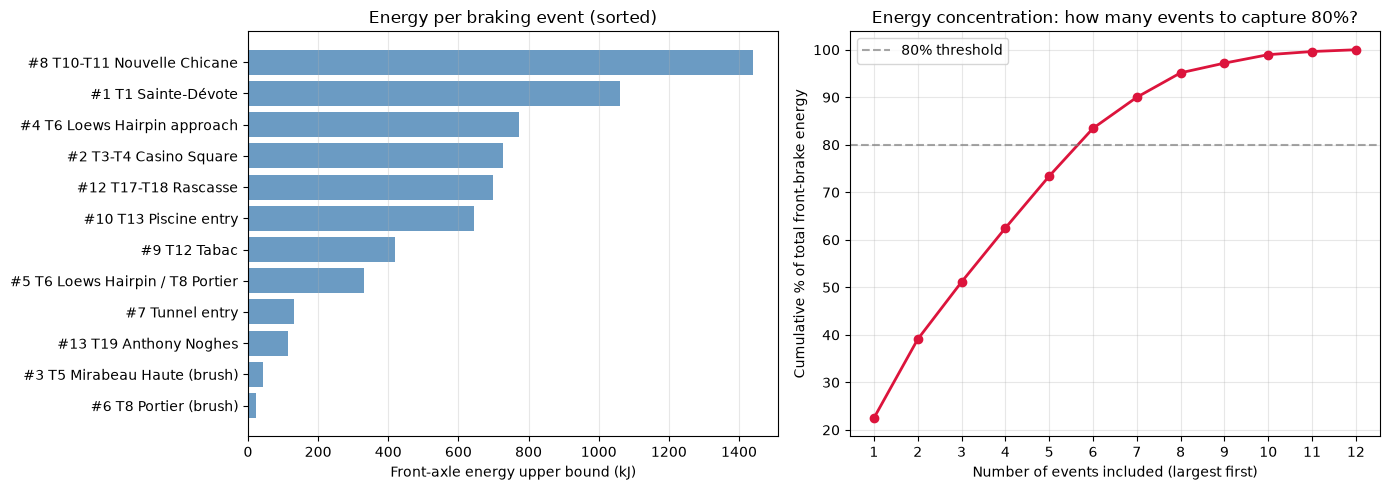


Total kinetic energy dissipated this lap: 11.43 MJ
Total front-axle energy (upper bound):    6.40 MJ
Per disc (split 50/50 left/right):        3.20 MJ

Lap time: 72.051 s
Avg continuous front-axle braking power: 88.9 kW


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: energy per event, sorted by magnitude
sorted_events = events_clean.sort_values('E_front_upper_kJ', ascending=True)
labels = [f"#{int(e)} {c}" for e, c in zip(sorted_events['event'], sorted_events['corner'])]
axes[0].barh(labels, sorted_events['E_front_upper_kJ'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Front-axle energy upper bound (kJ)')
axes[0].set_title('Energy per braking event (sorted)')
axes[0].grid(True, alpha=0.3, axis='x')

# Right: cumulative energy as we add events from largest to smallest
sorted_desc = events_clean.sort_values('E_front_upper_kJ', ascending=False).reset_index(drop=True)
cumulative_pct = sorted_desc['E_front_upper_kJ'].cumsum() / sorted_desc['E_front_upper_kJ'].sum() * 100
axes[1].plot(range(1, len(cumulative_pct) + 1), cumulative_pct, 
             marker='o', color='crimson', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].set_xlabel('Number of events included (largest first)')
axes[1].set_ylabel('Cumulative % of total front-brake energy')
axes[1].set_title('Energy concentration: how many events to capture 80%?')
axes[1].set_xticks(range(1, len(cumulative_pct) + 1))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Total summary
total_ke = events_clean['delta_KE_kJ'].sum()
total_front = events_clean['E_front_upper_kJ'].sum()
print(f"\nTotal kinetic energy dissipated this lap: {total_ke/1000:.2f} MJ")
print(f"Total front-axle energy (upper bound):    {total_front/1000:.2f} MJ")
print(f"Per disc (split 50/50 left/right):        {total_front/2/1000:.2f} MJ")
print(f"\nLap time: {fastest['LapTime'].total_seconds():.3f} s")
print(f"Avg continuous front-axle braking power: {total_front / fastest['LapTime'].total_seconds():.1f} kW")

## Summary: what this notebook established

**Session analyzed:** 2026 Monaco GP Qualifying, pole lap by ANT (Mercedes), 1:12.051

**Key findings:**

1. **FastF1 telemetry sample rate is ~7.5 Hz** for the 2026 season. This limits time resolution to ~133 ms. Event-level energy analysis (using start/end speeds) is robust to this; instantaneous deceleration is not.
2. **The pole lap contains 13 detected braking events.** After filtering (min duration 0.1s, min ΔV 5 km/h), 12 remain.
3. **Total kinetic energy dissipated per lap: ~11.4 MJ.** Front-axle upper-bound share (bias 0.56): ~6.4 MJ. Per front disc: ~3.2 MJ.
4. **Energy is highly concentrated:** the six largest events account for ~80% of the front-brake energy budget. Model accuracy on these six dominates total accuracy.
5. **Average front-axle braking power across the lap: ~89 kW.** Peak average-power during a single event: ~537 kW (Sainte-Dévote). Total energies are dominated by Nouvelle Chicane (~1.44 MJ to the front axle).
6. **Average decelerations are 0.5-2.1g.** Peaks are higher but unresolvable at 7.5 Hz.

**Implications for the physics model:**

- ΔKE per event becomes the heat input term in the thermal model
- The "upper bound" front-axle energy will reduce by 15-30% once drag, rolling resistance, and engine braking are subtracted
- Validation should weight errors by event energy, not event count
- Single-disc analysis is sufficient (left/right modeled identically per scope decision)

**Known limitations / open questions:**

- No ground truth for actual disc temperature or wear — validation will be physics-plausibility based
- Brake bias treated as fixed 56% (Phase 1a.5 may relax this)
- Corner-name mapping is approximate (best-effort by distance)
- Sample rate of 7.5 Hz means peak decelerations and short events are under-resolved